# Comparison from $16~$fb$^{-1}$ to $20~$fb$^{-1}$
## Compare the fit results with different datasets and different BOSS versions

### Function to pick out correct parameters

In [1]:
enum class WhichParameters{All, cisi, Ri, BF, deltaKpi};
const WhichParameters whichParameters = WhichParameters::cisi;

In [2]:
template<typename T>
std::vector<T> PickParameters(const std::vector<T> &vec) {
    switch(whichParameters) {
        case WhichParameters::All:
            return vec;
        case WhichParameters::cisi:
            return std::vector<T>(vec.begin() + 1, vec.begin() + 9);
        case WhichParameters::Ri:
            return std::vector<T>(vec.begin() + 9, vec.begin() + 16);
        case WhichParameters::BF:
            return std::vector<T>{vec[0], vec[16]};
        case WhichParameters::deltaKpi:
            return std::vector<T>{vec[17], vec[18]};
    }
}

### Bias corrections for $c_i$

In [3]:
std::vector<double> ci_No2024_pull{
    -0.141975,
    -0.0439872,
    -0.0576681,
    -0.102713
};
std::vector<double> ci_Only2024_pull{
    -0.0354041,
    -0.0738693,
    0.102518,
    0.0773291
};
std::vector<double> ci_Nominal_pull{
    -0.0836454,
    -0.0525307,
    -0.0060607,
    -0.0399436
};

### Load fit results

In [4]:
const std::string Path("/data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins_");
TFile File1((Path + "16fb/cisiFit/PreliminaryFitResults.root").c_str(), "READ");
std::vector<double> *FitValues1 = nullptr, *FitUncertainties1 = nullptr;
File1.GetObject("FitValues", FitValues1);
File1.GetObject("FitUncertainties", FitUncertainties1);
std::vector<double> FittedValues1 = PickParameters(*FitValues1);
std::vector<double> FittedUncertainties1 = PickParameters(*FitUncertainties1);

In [5]:
TFile File2((Path + "20fb_No2024/cisiFit/PreliminaryFitResults.root").c_str(), "READ");
std::vector<double> *FitValues2 = nullptr, *FitUncertainties2 = nullptr;
File2.GetObject("FitValues", FitValues2);
File2.GetObject("FitUncertainties", FitUncertainties2);
std::vector<double> FittedValues2 = PickParameters(*FitValues2);
std::vector<double> FittedUncertainties2 = PickParameters(*FitUncertainties2);

In [6]:
TFile File3((Path + "20fb/cisiFit/PreliminaryFitResults.root").c_str(), "READ");
std::vector<double> *FitValues3 = nullptr, *FitUncertainties3 = nullptr;
File3.GetObject("FitValues", FitValues3);
File3.GetObject("FitUncertainties", FitUncertainties3);
std::vector<double> FittedValues3 = PickParameters(*FitValues3);
std::vector<double> FittedUncertainties3 = PickParameters(*FitUncertainties3);

In [7]:
TFile File4((Path + "20fb_Only2024/cisiFit/PreliminaryFitResults.root").c_str(), "READ");
std::vector<double> *FitValues4 = nullptr, *FitUncertainties4 = nullptr;
File4.GetObject("FitValues", FitValues4);
File4.GetObject("FitUncertainties", FitUncertainties4);
std::vector<double> FittedValues4 = PickParameters(*FitValues4);
std::vector<double> FittedUncertainties4 = PickParameters(*FitUncertainties4);

In [8]:
TFile File5((Path + "20fb_Only2022/cisiFit/PreliminaryFitResults.root").c_str(), "READ");
std::vector<double> *FitValues5 = nullptr, *FitUncertainties5 = nullptr;
File5.GetObject("FitValues", FitValues5);
File5.GetObject("FitUncertainties", FitUncertainties5);
std::vector<double> FittedValues5 = PickParameters(*FitValues5);
std::vector<double> FittedUncertainties5 = PickParameters(*FitUncertainties5);

In [9]:
TFile File6((Path + "20fb_OnlyOld/cisiFit/PreliminaryFitResults.root").c_str(), "READ");
std::vector<double> *FitValues6 = nullptr, *FitUncertainties6 = nullptr;
File6.GetObject("FitValues", FitValues6);
File6.GetObject("FitUncertainties", FitUncertainties6);
std::vector<double> FittedValues6 = PickParameters(*FitValues6);
std::vector<double> FittedUncertainties6 = PickParameters(*FitUncertainties6);

### Variable names

In [10]:
 std::vector<std::string> VariableNames{"BF",
                                        "c_{1}", "c_{2}", "c_{3}", "c_{4}",
                                        "s_{1}", "s_{2}", "s_{3}", "s_{4}",
                                        "R_{-4}", "R_{-3}", "R_{-2}", "R_{-1}",
                                        "R_{1}", "R_{2}", "R_{3}",
                                        "BF_{K_{L}#pi#pi}",
                                        "r_{D}cos(#delta_{K#pi})", "r_{D}sin(#delta_{K#pi})"};
VariableNames = PickParameters(VariableNames);

### Order of parameters

In [11]:
std::vector<double> VariableNumber1(FittedValues1.size()),
                    VariableNumber2(FittedValues2.size()),
                    VariableNumber3(FittedValues3.size()),
                    VariableNumber4(FittedValues4.size()),
                    VariableNumber5(FittedValues5.size()),
                    VariableNumber6(FittedValues6.size());
std::iota(VariableNumber1.begin(), VariableNumber1.end(), 0.2);
//std::reverse(VariableNumber1.begin(), VariableNumber1.end());
for(std::size_t i = 0; i < VariableNumber1.size(); i++) {
    VariableNumber2[i] = VariableNumber1[i] + 0.08;
    VariableNumber3[i] = VariableNumber1[i] + 0.16;
    VariableNumber4[i] = VariableNumber1[i] + 0.24;
    VariableNumber5[i] = VariableNumber1[i] + 0.32;
    VariableNumber6[i] = VariableNumber1[i] + 0.40;
}

### Shift central values

In [12]:
for(std::size_t i = 0; i < FittedValues1.size(); i++) {
    FittedValues2[i] -= FittedValues1[i];
    FittedValues3[i] -= FittedValues1[i];
    FittedValues4[i] -= FittedValues1[i];
    FittedValues5[i] -= FittedValues1[i];
    FittedValues6[i] -= FittedValues1[i];
    FittedValues1[i] = 0.0;
}

### Correct for biases

In [13]:
if(whichParameters == WhichParameters::cisi) {
    for(std::size_t i = 0; i < 4; i++) {
        FittedValues2[i] -= ci_No2024_pull[i]*FittedUncertainties2[i];
        FittedValues3[i] -= ci_Nominal_pull[i]*FittedUncertainties3[i];
        FittedValues4[i] -= ci_Only2024_pull[i]*FittedUncertainties4[i];
        FittedValues5[i] -= ci_Only2024_pull[i]*FittedUncertainties5[i];
        FittedValues6[i] -= ci_Only2024_pull[i]*FittedUncertainties6[i];
    }
}

### Make plot

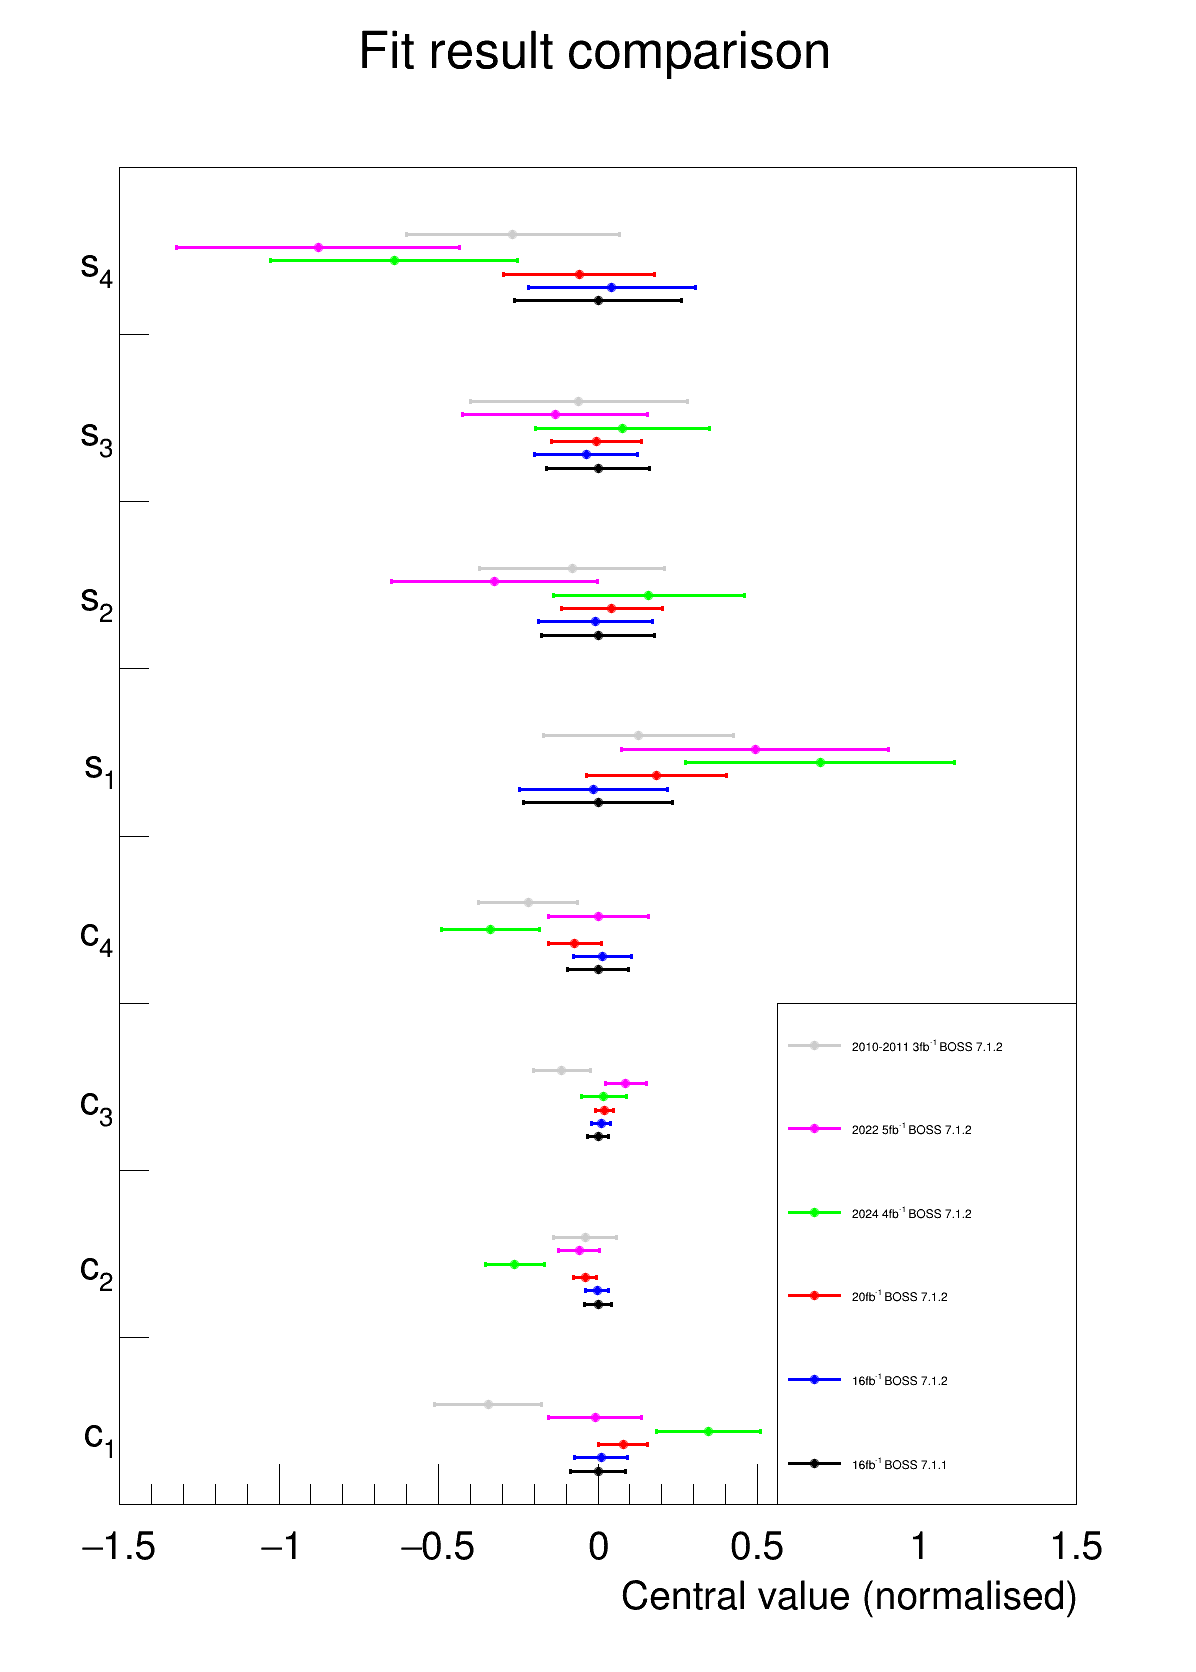

In [14]:
TCanvas c("c", "", 1200, 100 + 200*FittedValues1.size());
TGraphErrors Graph1(FittedValues1.size(),
                    FittedValues1.data(),
                    VariableNumber1.data(),
                    FittedUncertainties1.data(),
                    nullptr);
TGraphErrors Graph2(FittedValues2.size(),
                    FittedValues2.data(),
                    VariableNumber2.data(),
                    FittedUncertainties2.data(),
                    nullptr);
TGraphErrors Graph3(FittedValues3.size(),
                    FittedValues3.data(),
                    VariableNumber3.data(),
                    FittedUncertainties3.data(),
                    nullptr);
TGraphErrors Graph4(FittedValues4.size(),
                    FittedValues4.data(),
                    VariableNumber4.data(),
                    FittedUncertainties4.data(),
                    nullptr);
TGraphErrors Graph5(FittedValues5.size(),
                    FittedValues5.data(),
                    VariableNumber5.data(),
                    FittedUncertainties5.data(),
                    nullptr);
TGraphErrors Graph6(FittedValues6.size(),
                    FittedValues6.data(),
                    VariableNumber6.data(),
                    FittedUncertainties6.data(),
                    nullptr);
Graph1.SetTitle("Fit result comparison;Central value (normalised);");
Graph1.SetLineWidth(3);
Graph1.SetMarkerStyle(8);
Graph2.SetLineWidth(3);
Graph2.SetMarkerStyle(8);
Graph3.SetLineWidth(3);
Graph3.SetMarkerStyle(8);
Graph4.SetLineWidth(3);
Graph4.SetMarkerStyle(8);
Graph5.SetLineWidth(3);
Graph5.SetMarkerStyle(8);
Graph6.SetLineWidth(3);
Graph6.SetMarkerStyle(8);
Graph1.SetMinimum(0.0);
Graph1.SetMaximum(FittedValues1.size());
Graph1.SetMarkerColor(kBlack);
Graph2.SetMarkerColor(kBlue);
Graph3.SetMarkerColor(kRed);
Graph4.SetMarkerColor(kGreen);
Graph5.SetMarkerColor(kMagenta);
Graph6.SetMarkerColor(kGray);
Graph1.SetLineColor(kBlack);
Graph2.SetLineColor(kBlue);
Graph3.SetLineColor(kRed);
Graph4.SetLineColor(kGreen);
Graph5.SetLineColor(kMagenta);
Graph6.SetLineColor(kGray);
Graph1.GetYaxis()->SetNdivisions(-FittedValues1.size());
Graph1.GetYaxis()->ChangeLabel(1, -1, 0, -1, -1, -1, "Hi");
for(std::size_t i = 0; i < VariableNames.size(); i++) {
    Graph1.GetYaxis()->ChangeLabel(i + 2, -1, -1, -1, -1, -1,
                                   ("#lower[3.0]{" + VariableNames[i] + "}").c_str());
}
switch(whichParameters) {
    case WhichParameters::cisi:
        Graph1.GetXaxis()->SetLimits(-1.5, 1.5);
        break;
    case WhichParameters::Ri:
        Graph1.GetXaxis()->SetLimits(-0.03, 0.03);
        break;
    case WhichParameters::BF:
        Graph1.GetXaxis()->SetLimits(-0.0003, 0.0003);
        break;
}
Graph1.Draw("AP E1");
Graph2.Draw("P E1 SAME");
Graph3.Draw("P E1 SAME");
Graph4.Draw("P E1 SAME");
Graph5.Draw("P E1 SAME");
Graph6.Draw("P E1 SAME");
TLegend Legend(0.65, 0.1, 0.9, 0.4);
Legend.AddEntry(&Graph6, "2010-2011 3fb^{-1} BOSS 7.1.2");
Legend.AddEntry(&Graph5, "2022 5fb^{-1} BOSS 7.1.2");
Legend.AddEntry(&Graph4, "2024 4fb^{-1} BOSS 7.1.2");
Legend.AddEntry(&Graph3, "20fb^{-1} BOSS 7.1.2");
Legend.AddEntry(&Graph2, "16fb^{-1} BOSS 7.1.2");
Legend.AddEntry(&Graph1, "16fb^{-1} BOSS 7.1.1");
Legend.Draw();
c.Draw();

In [15]:
switch(whichParameters) {
    case WhichParameters::All:
        break;
    case WhichParameters::cisi:
        c.SaveAs("Comparison_16_20_fb_cisi.pdf");
        break;
    case WhichParameters::Ri:
        c.SaveAs("Comparison_16_20_fb_Ri.pdf");
        break;
    case WhichParameters::BF:
        c.SaveAs("Comparison_16_20_fb_BF.pdf");
        break;
    case WhichParameters::deltaKpi:
        c.SaveAs("Comparison_16_20_fb_deltaKpi.pdf");
        break;
}
c.Close();

Info in <TCanvas::Print>: pdf file Comparison_16_20_fb_cisi.pdf has been created


### Quick calculation of significance

In [17]:
std::size_t i = FittedValues2.size();
while(i != 0) {
    i--;
    double Diff = TMath::Abs(FittedValues2[i] - FittedValues6[i]);
    double UncSum2 = TMath::Power(FittedUncertainties2[i], 2)
                   - TMath::Power(FittedUncertainties6[i], 2);
    std::cout << Diff/TMath::Sqrt(TMath::Abs(UncSum2)) << "\n";
}

1.47815
0.0772923
0.319918
0.758515
1.85031
1.45243
0.420273
2.43723
